In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)
pd.set_option("display.precision", 2)

plt.style.use('dark_background')

# Read file

# Load and clean text

In [2]:
data_folder = 'C:/Users/Graham West/Python Notebooks/Meharry Teaching/Datasets/'
data_folder = data_folder + "Text Processing/"

with open(data_folder + 'bible.txt') as f:
    text = f.read()

print(text[:300])

Genesis 1:1	In the beginning God created the heaven and the earth.
Genesis 1:2	And the earth was without form, and void; and darkness [was] upon the face of the deep. And the Spirit of God moved upon the face of the waters.
Genesis 1:3	And God said, Let there be light: and there was light.
Genesis 1


In [3]:
books = {}

for line in text.split('\n'):
    line = line.strip()
    if not line:
        continue

    # Match: BookName chapter:verse <whitespace> text
    m = re.match(r"^([A-Za-z0-9 ]+)\s+(\d+):(\d+)\s+(.*)$", line)
    if not m:
        continue

    book = m.group(1)
    verse_text = m.group(4)
    verse_text = verse_text.lower()
    verse_text = re.sub(r'\s+', ' ', verse_text)
    verse_text = re.sub(r'[^a-z\'\s]', '', verse_text)
    
    if book not in books:
        books[book] = []

    books[book].append(verse_text)

# Join verses into full-book text
books = {book: " ".join(text).strip() for book, text in books.items()}

In [4]:
books['Genesis'][:500]

'in the beginning god created the heaven and the earth and the earth was without form and void and darkness was upon the face of the deep and the spirit of god moved upon the face of the waters and god said let there be light and there was light and god saw the light that it was good and god divided the light from the darkness and god called the light day and the darkness he called night and the evening and the morning were the first day and god said let there be a firmament in the midst of the w'

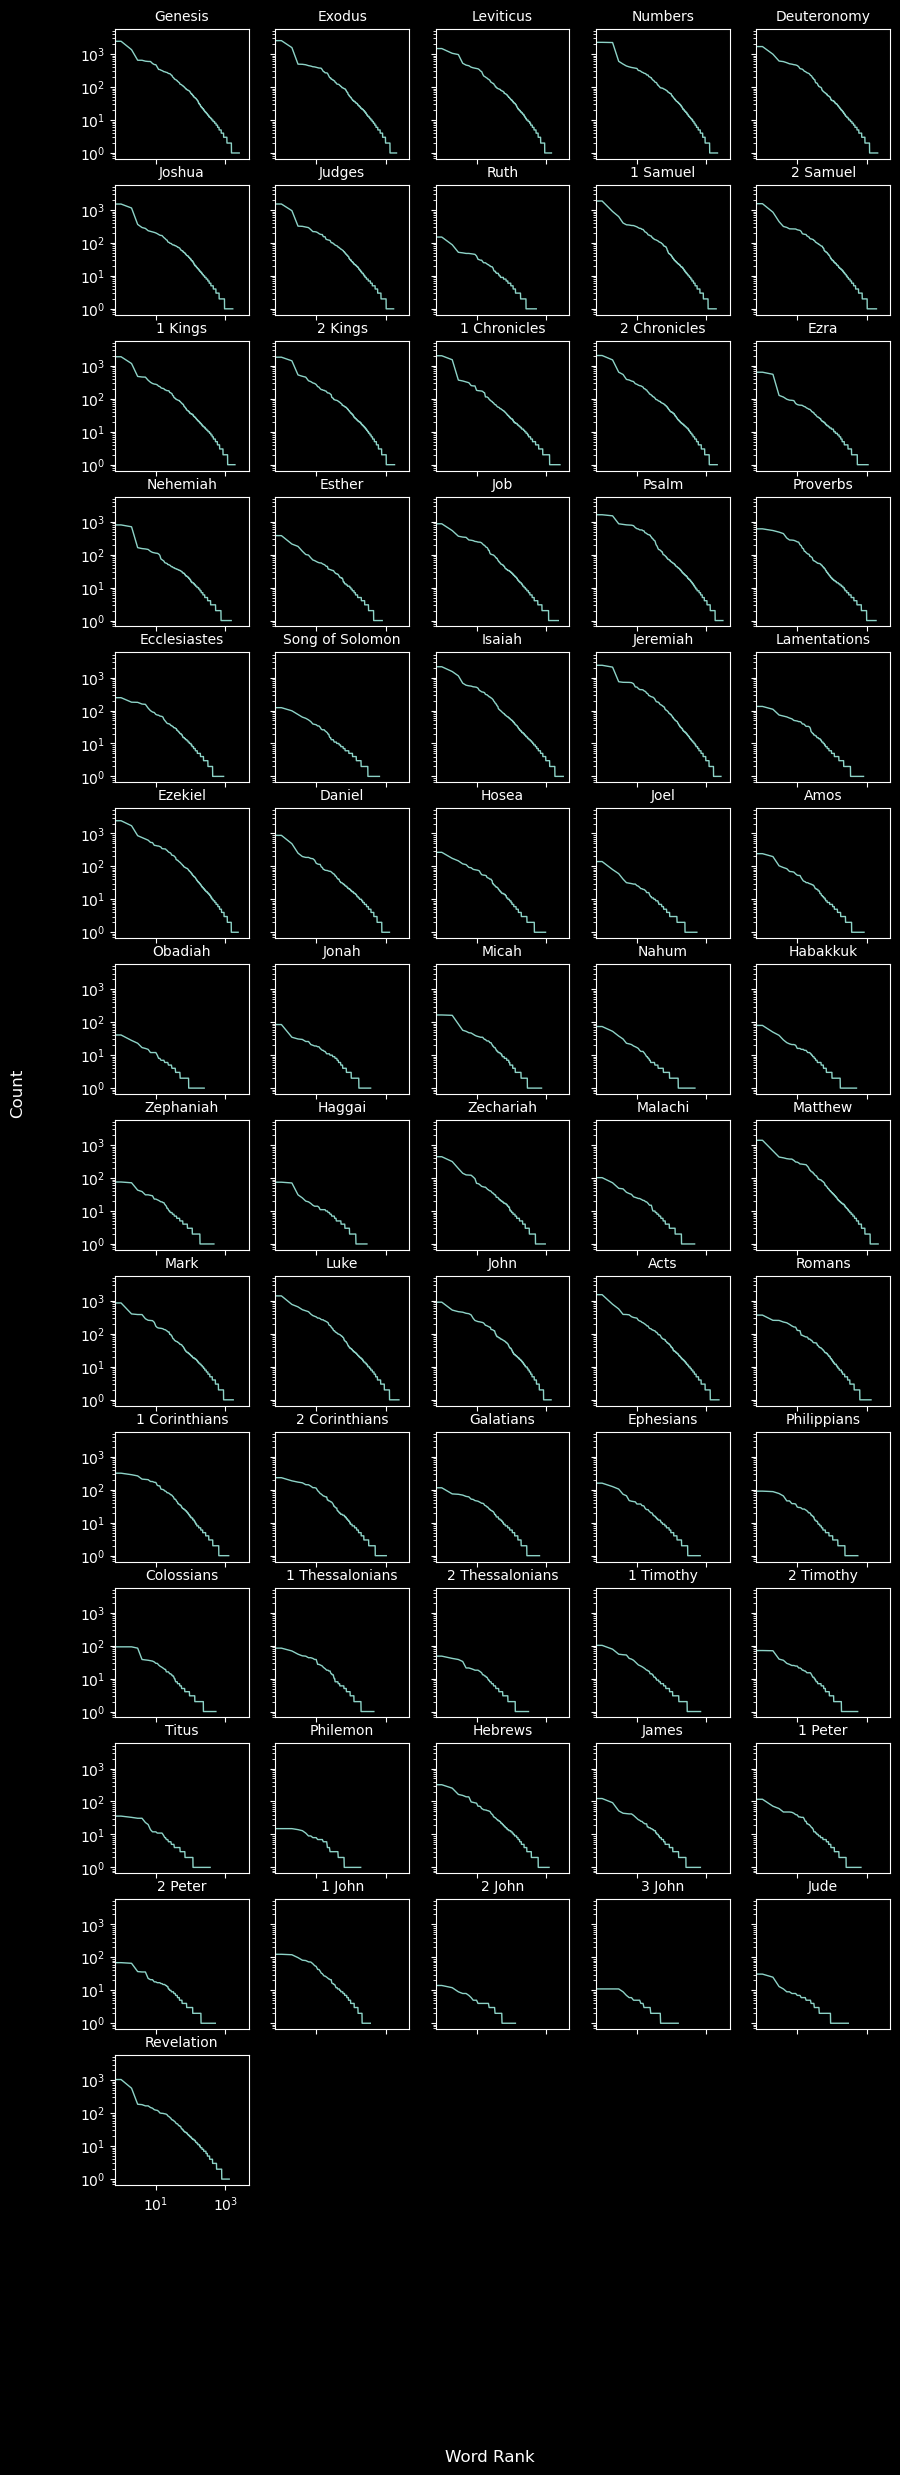

In [5]:
words_all = {}

for book in books.keys():
    words_all[book] = pd.Series(books[book].split())

book_names = list(words_all.keys())
n_books = len(book_names)

# Choose grid shape (roughly square)
n_cols = 5
n_rows = int(np.ceil(n_books / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2 * n_cols, 2 * n_rows),
    sharex=True,
    sharey=True
)

axes = np.array(axes).reshape(-1)

for ax, book in zip(axes, books):
    vc = words_all[book].value_counts()
    ax.loglog(vc.values, linewidth=1)
    ax.set_title(book, fontsize=10)

# Remove unused axes
for ax in axes[len(books):]:
    ax.axis("off")

fig.supxlabel("Word Rank")
fig.supylabel("Count")

plt.show()

# Encode text

In [6]:
books = ["John"]

words_combined = []
for book in books:
    words_combined.extend(words_all[book])

gram_len = 1
grams = []
for i in range(len(words_combined) - gram_len + 1):
    grams.append(" ".join(words_combined[i:i+gram_len]))

grams = np.array(grams)
vocab = np.unique(grams)
vocab.shape

(1391,)

In [7]:
n_grams = grams.shape[0]
n_vocab = vocab.shape[0]

from sklearn.preprocessing import LabelEncoder
LE = LabelEncoder()
vocab_enc = LE.fit_transform(vocab).astype(int)
grams_enc = LE.transform(grams).astype(int)

# Get transition probabilities

In [8]:
P = np.zeros((n_vocab,n_vocab))

for i in range(n_grams-1):
    jj = grams_enc[i]
    kk = grams_enc[i+1]
    P[jj,kk] += 1
# end

In [9]:
# normalize rows
for i in range(n_vocab):
    #P[i,:] = P[i,:] ** 2
    tot = P[i,:].sum()
    if tot > 0:
        P[i,:] = P[i,:] / tot
    # end
# end

# Get SVD word embeddings

In [11]:
# --- Flags ---
use_smooth_P = False
use_both_UV  = True

# --- Smooth P by summing powers ---
if use_smooth_P:
    P_input = np.zeros_like(P)
    Pi = np.eye(P.shape[0])
    for step in range(1, 4):
        Pi = Pi @ P
        P_input += Pi / step  # downweight longer steps
else:
    P_input = P

# --- SVD ---
from sklearn.utils.extmath import randomized_svd
k = 50
U, S, Vt = randomized_svd(P_input, n_components=k+1, random_state=42)

U_embed = U[:, 1:] * np.sqrt(S[1:])
V_embed = Vt.T[:, 1:] * np.sqrt(S[1:])

if use_both_UV:
    embeddings = np.hstack([U_embed, V_embed])  # shape: (n_vocab, 2k)
else:
    embeddings = U_embed  # shape: (n_vocab, k)

# --- Dimensionality reduction ---
use_tsne = True
if use_tsne:
    from sklearn.manifold import TSNE
    tsne = TSNE(n_components=2, perplexity=50, random_state=42)
    coords = tsne.fit_transform(embeddings)
else:
    coords = embeddings[:, :2]

In [ ]:
words_to_label = [
    # Divinity & worship
    'god', 'lord', 'holy', 'spirit', 'angel', 'devil', 'worship', 'prayer',

    # Synonyms for ruler/authority
    'king', 'prince', 'pharaoh', 'captain', 'servant',

    # Man/woman + family
    'man', 'woman', 'father', 'mother', 'son', 'daughter', 'wife', 'husband',

    # Moral opposites
    'love', 'hate', 'good', 'evil', 'righteous', 'wicked', 'blessed', 'cursed',

    # Life & death
    'born', 'death', 'blood', 'flesh', 'soul', 'alive',

    # War & violence
    'sword', 'war', 'battle', 'enemy', 'bow', 'spear',

    # Nature & land
    'water', 'land', 'sea', 'fire', 'stone', 'wilderness',

    # Food & sustenance
    'bread', 'wine', 'oil', 'grain', 'famine', 'feast',

    # Emotion & inner life
    'heart', 'fear', 'joy', 'sorrow', 'anger', 'mercy',
]

from sklearn.metrics.pairwise import cosine_similarity

# Filter to only labeled words that exist in vocab
valid_words = [w for w in words_to_label if w in LE.classes_]
valid_idx = [LE.transform([w])[0] for w in valid_words]

# Extract embeddings for labeled words and compute cosine sim
labeled_embeddings = embeddings[valid_idx]
cos_sim = cosine_similarity(labeled_embeddings)

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cos_sim,
    xticklabels=valid_words,
    yticklabels=valid_words,
    #cmap='coolwarm',
    #center=0,
    #vmin=-1, vmax=1,
    ax=ax,
    square=True,
    linewidths=0.3,
)
ax.set_title("Cosine similarity between labeled words (SVD embeddings)", fontsize=14)
plt.xticks(fontsize=10, rotation=45, ha='right')
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords[:, 0], coords[:, 1], s=2, alpha=0.3, color='steelblue')

for word in words_to_label:
    if word in LE.classes_:
        i = LE.transform([word])[0]
        ax.scatter(*coords[i], s=40, color='tomato', zorder=5)
        ax.annotate(word, coords[i], fontsize=8, color='white',
                    xytext=(0, 8), textcoords='offset points',
                    ha='center', va='bottom')

ax.set_title("SVD embedding of Bible word transition matrix (t-SNE)", fontsize=14)
plt.tight_layout()
plt.show()